<a href="https://colab.research.google.com/github/silvia-dev-prog/ai-agents-for-beginners/blob/main/Tanques_Acoplados_Parte_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Técnicas de Inteligência Artificial Aplicadas às Engenharias de Processos**

28 de janeiro de 2026 | Extensão FEQ UNICAMP

Professor: Vitor Oliveira

# **Módulo 8 - Aula 2 | Controle Fuzzy**


# Controle Fuzzy

Considere o seguinte processo:
Têm-se um sistema de tanques acoplados e uma bomba d'água. Os
dois tanques são ligados em série, ou seja, o tanque 1 recebe água da bomba e o tanque 2 recebe a água do tanque.

O objetivo de controle desse sistema é manter o nível do tanque 2 em setpoints pré-estabelecidos por meio da implementação de controladores
convencionais (controlador PID), devidamente sintonizados, e controladores “inteligentes” com uso da lógica fuzzy.

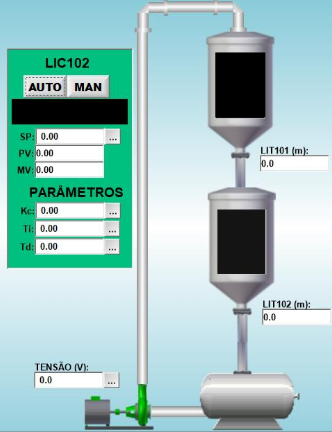

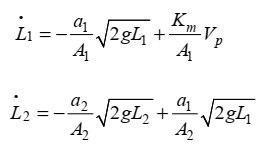

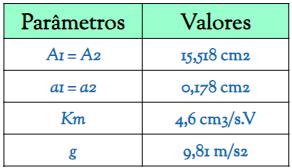

# Controle PID

O modelo não linear descrito pelas equações abaixo já foi implementado pela equipe do laboratório:

In [ ]:
!pip install simple_pid

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
from sympy import symbols,Eq,solve
import matplotlib.pyplot as plt
from scipy.integrate import odeint
from simple_pid import PID
plt.rcParams['figure.figsize'] = 25,5

In [ ]:
#Construção do modelo com as EDOs advindas dos BM
def modelo(L, t, Vp, a, A, g, Km):
    L1 = np.maximum(0, L[0])
    L2 = np.maximum(0, L[1])
    dL1dt = -(a/A)*np.sqrt(2*g*L1) + Km/A*Vp
    dL2dt = -(a/A)*np.sqrt(2*g*L2) + a/A*np.sqrt(2*g*L1)
    return [dL1dt, dL2dt]

#Definição da função de solução das EDOs
def solver(f, init_state, params, dt):
    return odeint(f, init_state, np.linspace(0, dt, 2), args=params)[-1]

Além da modelagem, já foi implementado o algoritmo de simulação com dois controladores PID. Os controladores convencionais foram testados em três pontos de operação (set-points) 5cm, 25 cm e 15cm. Sabe-se que o PID1 foi projetado para apresentar um desempenho esperado no ponto de operação 5cm de nível do tanque 2 e o PID2 foi projetado no ponto de operação 25cm de nível do mesmo tanque.

In [ ]:
dt = 0.1 #Intervalo de amostragem
t = 300 #min Tempo total da simulação

A = 15.518 #cm2
a = 1.78 #cm2
Km = 4.6 #cm3/s.V
g = 9.81 * 100 #cm/s2

In [ ]:
def plot_results_pid(time, L2, V, erro, colors=['r','g','b']):
    plt.figure(figsize=(15,10))
    plt.subplot(3,1,1)
    plt.plot(time, L2[:-1], label='Nível do Tanque 2 (cm)', color=colors[0])
    plt.axhline(5, color='r', linestyle='--', label='Setpoint 1 (5 cm)')
    plt.axhline(25, color='g', linestyle='--', label='Setpoint 2 (25 cm)')
    plt.axhline(15, color='b', linestyle='--', label='Setpoint 3 (15 cm)')
    plt.title('Resposta do Sistema com Controlador PID1 (Ruído Baixo)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Nível do Tanque 2 (cm)')
    plt.legend()
    plt.grid()
    plt.subplot(3,1,2)
    plt.plot(time, V[:-1], label='Ação de Controle (V)', color=colors[1])
    plt.title('Ação de Controle com Controlador PID1 (Ruído Baixo)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Ação de Controle (V)')
    plt.legend()
    plt.grid()
    plt.subplot(3,1,3)
    plt.plot(time, erro[:-1], label='Erro (cm)', color=colors[2])
    plt.title('Erro com Controlador PID1 (Ruído Baixo)')
    plt.xlabel('Tempo (s)')
    plt.ylabel('Erro (cm)')
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

In [ ]:
def simulation_pid(pid, time, dt, a, A, g, Km, t, noise_level=0):
    #Iniciando as listas de armazenamento
    L1_pid=[0]
    L2_pid=[0]
    V_pid=[0]
    erro_pid=[0]

    noise = np.random.randn(len(time))*noise_level

    #Lógica do controle para o PID1
    for i in range(len(time)):

        #Definindo o setpoint conforme o tempo
        if time[i] < t/3:
            pid.setpoint = 5  # Setpoint 1
        elif time[i] < 2*t/3:
            pid.setpoint = 25  # Setpoint 2
        else:
            pid.setpoint = 15  # Setpoint 3

        MV = pid(L2_pid[-1], dt=dt) #Entrega PV atual para o controlador
        V_pid.append(MV)

        PV = solver(modelo, [L1_pid[-1], L2_pid[-1]], (MV, a, A, g, Km), dt)

        #adicionando ruído à medição
        if (PV[0] + noise[i] > 0) & (PV[1] + noise[i] > 0):
          PV[0] =  PV[0] + noise[i] #input de ruído
          PV[1] =  PV[1] + noise[i] #input de ruído

        erro_pid.append(pid.setpoint - PV[1])

        L1_pid.append(PV[0])
        L2_pid.append(PV[1])
    return L1_pid, L2_pid, V_pid, erro_pid


In [ ]:
import numpy as np
from simple_pid import PID

#Organizando os ganhos em vetores
kc = np.array([5, 5]) #V/cm
ki = np.array([5/0.5, 5/2]) #s
kd = np.array([1.5*5, 1.5*5]) #s

t = 300  # total time
dt = 0.1  # time step

time = np.arange(0, t, dt)

#Rodando primeiro para o Controlador PID1
pid1 = PID(kc[0], ki[0], kd[0], setpoint=5)

#Rodar para PID1 e ruido baixo
L1_pid1, L2_pid1, V_pid1, erro_pid1 = simulation_pid(pid1, time, dt, a, A, g, Km, t, noise_level=0.25)

In [ ]:
pid2 = PID(kc[1], ki[1], kd[1], setpoint=5)

#Rodar para PID2 e ruido baixo
L1_pid2, L2_pid2, V_pid2, erro_pid2 = simulation_pid(pid2, time, dt, a, A, g, Km, t, noise_level=0.25)

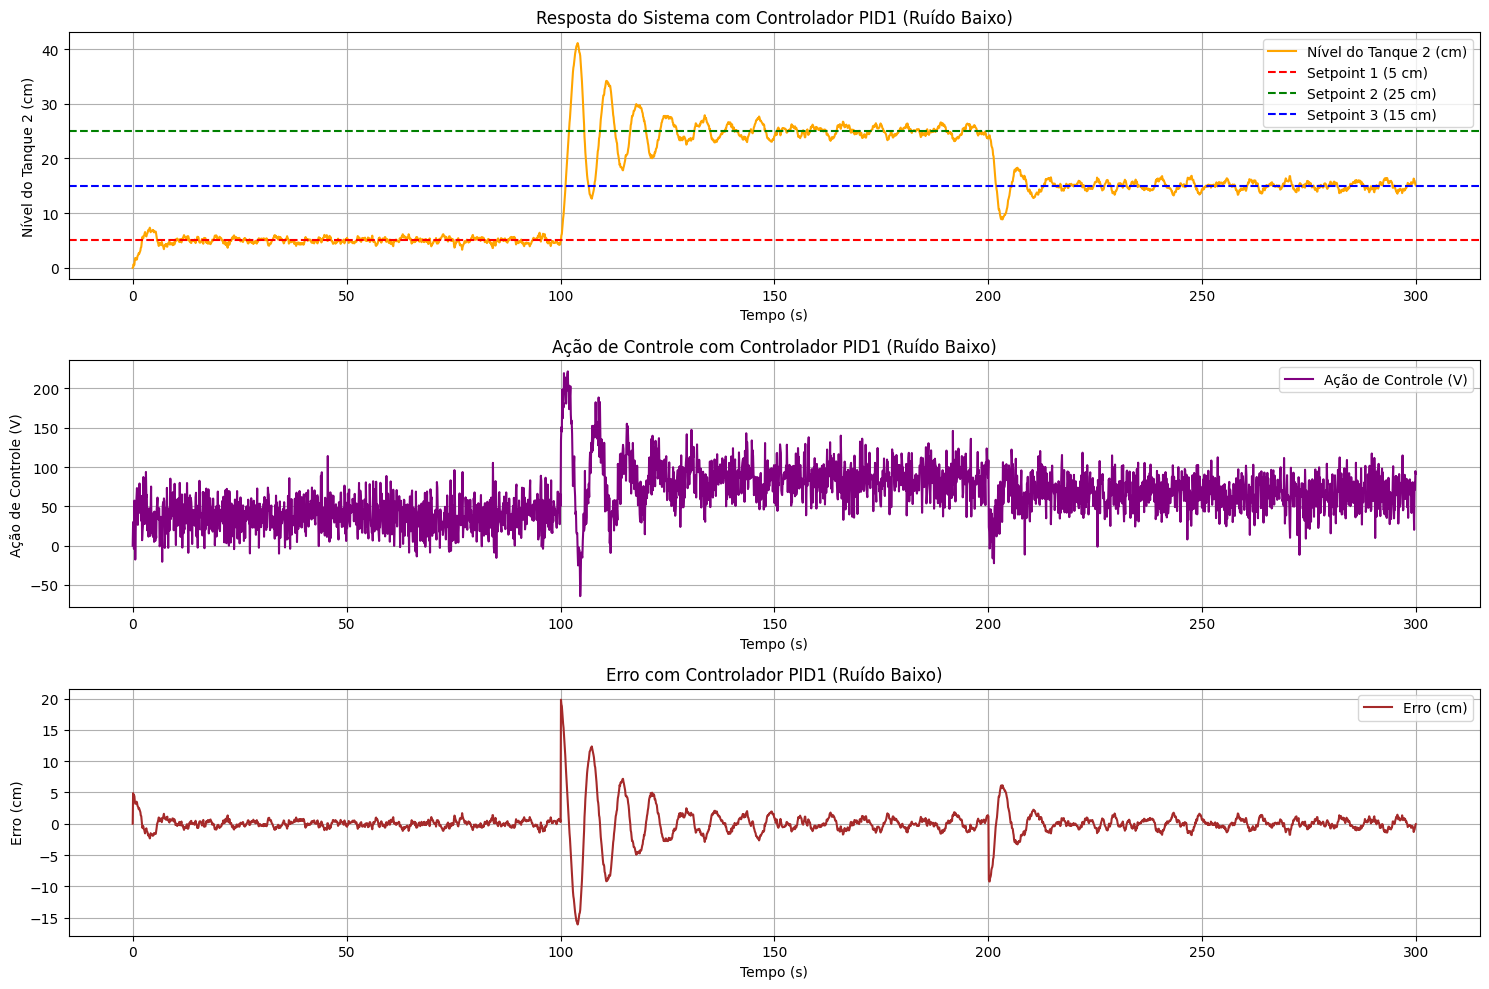

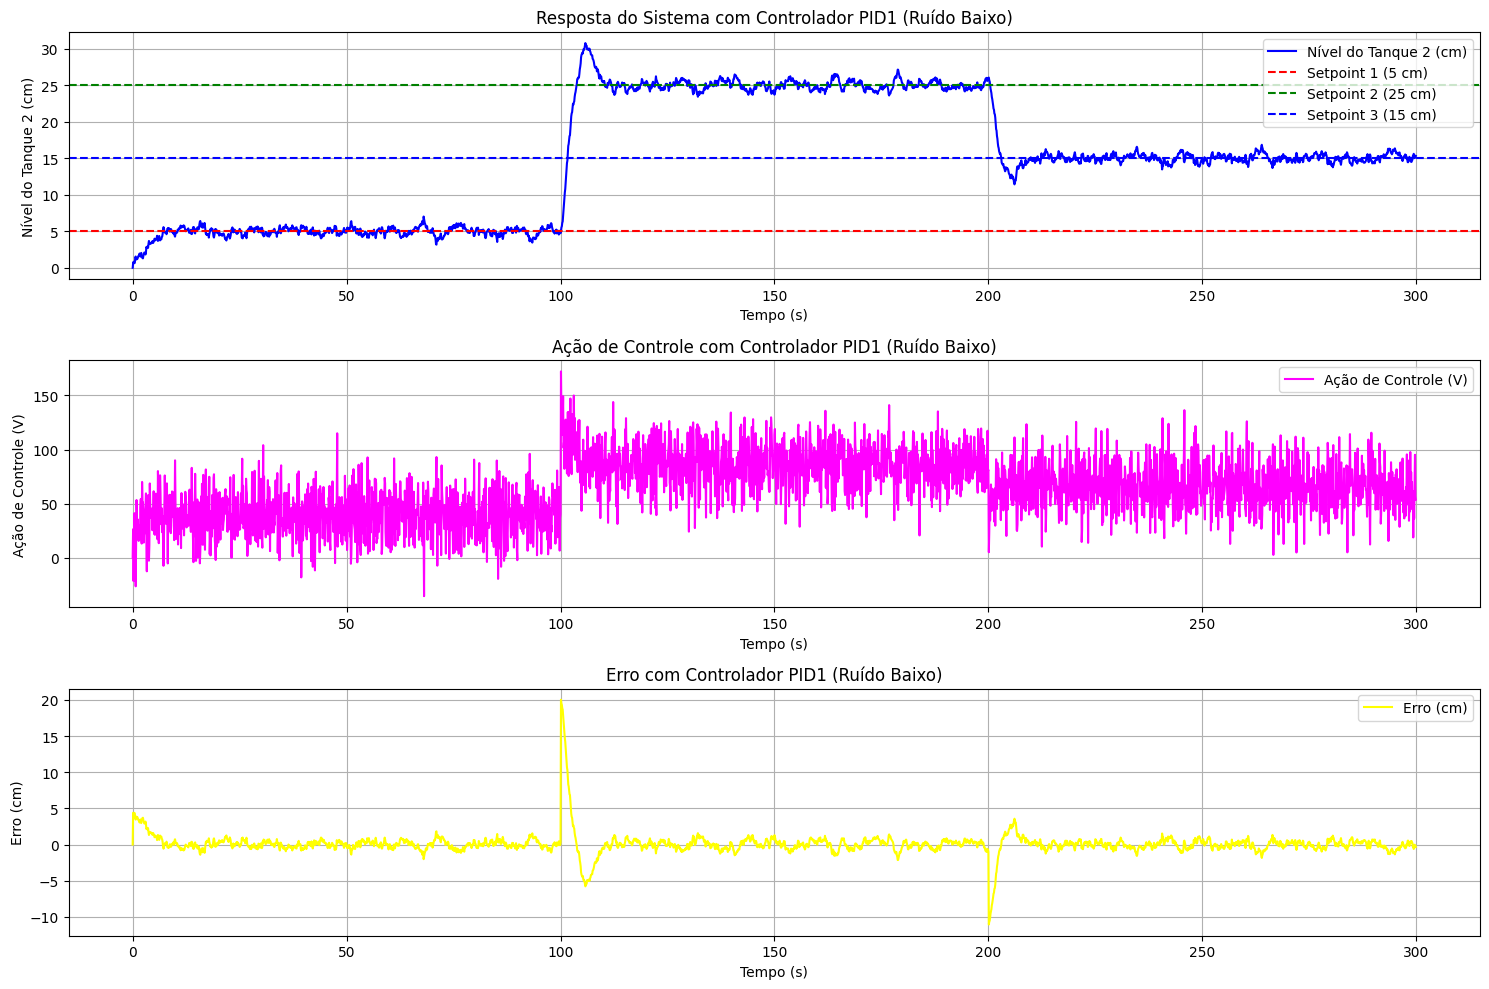

In [ ]:
#Plotar para resultados PID1
plot_results_pid(time, L2_pid1, V_pid1, erro_pid1, colors=['orange','purple','brown'])
#Plotar para resultados PID2
plot_results_pid(time, L2_pid2, V_pid2, erro_pid2, colors=['blue','magenta','yellow'])

In [ ]:
#Comparação das métricas de desempenho IAE, ISE, ITAE e ITSE

def performance_metrics(erro, time):
    erro = np.array(erro)
    IAE = np.sum(np.abs(erro))
    ISE = np.sum(erro**2)
    ITAE = np.sum(time * np.abs(erro))
    ITSE = np.sum(time * (erro**2))
    return IAE, ISE, ITAE, ITSE

#Excluir primeiro dado de erro_pid1 e erro_pid2 para alinhar com o tempo
erro_pid1_corr = erro_pid1[1:]
erro_pid2_corr = erro_pid2[1:]

metrics_pid1 = performance_metrics(erro_pid1_corr, time)
metrics_pid2 = performance_metrics(erro_pid2_corr, time)

df_metrics = pd.DataFrame({
    'PID1': metrics_pid1,
    'PID2': metrics_pid2
}, index=['IAE', 'ISE', 'ITAE', 'ITSE'])

df_metrics

,PID1,PID2
IAE,3.430615e+03,2149.677554
ISE,1.702796e+04,8064.072688
ITAE,4.765025e+05,294892.689744
ITSE,2.023067e+06,960518.497105


In [ ]:
#Refazer análise nos 3 terços da simulação individualmente para cada PID

#Primeiro terço
time_third1 = time[time < t/3]
erro_pid1_third1 = erro_pid1_corr[:len(time_third1)]
erro_pid2_third1 = erro_pid2_corr[:len(time_third1)]

#Segundo terço
time_third2 = time[(time >= t/3) & (time < 2*t/3)]
erro_pid1_third2 = erro_pid1_corr[len(time_third1):len(time_third1)+len(time_third2)]
erro_pid2_third2 = erro_pid2_corr[len(time_third1):len(time_third1)+len(time_third2)]

#Terceiro terço
time_third3 = time[time >= 2*t/3]
erro_pid1_third3 = erro_pid1_corr[len(time_third1)+len(time_third2):]
erro_pid2_third3 = erro_pid2_corr[len(time_third1)+len(time_third2):]

metrics_pid1_third1 = performance_metrics(erro_pid1_third1, time_third1)
metrics_pid1_third2 = performance_metrics(erro_pid1_third2, time_third2)
metrics_pid1_third3 = performance_metrics(erro_pid1_third3, time_third3)

metrics_pid2_third1 = performance_metrics(erro_pid2_third1, time_third1)
metrics_pid2_third2 = performance_metrics(erro_pid2_third2, time_third2)
metrics_pid2_third3 = performance_metrics(erro_pid2_third3, time_third3)

df_metrics_thirds = pd.DataFrame({
    'PID1_Third1': metrics_pid1_third1,
    'PID1_Third2': metrics_pid1_third2,
    'PID1_Third3': metrics_pid1_third3,
    'PID2_Third1': metrics_pid2_third1,
    'PID2_Third2': metrics_pid2_third2,
    'PID2_Third3': metrics_pid2_third3
}, index=['IAE', 'ISE', 'ITAE', 'ITSE'])

#Fazer uma coluna indicando o melhor PID em cada terço
best_pid = []
for i in range(len(df_metrics_thirds)):
    third1_best = 'PID1' if df_metrics_thirds.iloc[i]['PID1_Third1'] < df_metrics_thirds.iloc[i]['PID2_Third1'] else 'PID2'
    third2_best = 'PID1' if df_metrics_thirds.iloc[i]['PID1_Third2'] < df_metrics_thirds.iloc[i]['PID2_Third2'] else 'PID2'
    third3_best = 'PID1' if df_metrics_thirds.iloc[i]['PID1_Third3'] < df_metrics_thirds.iloc[i]['PID2_Third3'] else 'PID2'
    best_pid.append((third1_best, third2_best, third3_best))
df_metrics_thirds['Best_PID'] = best_pid
df_metrics_thirds

,PID1_Third1,PID1_Third2,PID1_Third3,PID2_Third1,PID2_Third2,PID2_Third3,Best_PID
IAE,480.073069,2.105987e+03,844.554632,537.687648,972.533595,639.456312,"(PID1, PID2, PID2)"
ISE,500.300337,1.446742e+04,2060.239546,712.424202,5680.038808,1671.609677,"(PID1, PID2, PID2)"
ITAE,19986.436510,2.586676e+05,197848.415880,21220.339336,123312.176939,150360.173469,"(PID1, PID2, PID2)"
ITSE,12264.421998,1.571438e+06,439364.628269,15151.426166,594679.046346,350688.024593,"(PID1, PID2, PID2)"


# Tarefa 1

---



Desenvolva um sistema fuzzy baseado em observações heurísticas, que resulte em um conjunto controlador híbrido que apresente um resultado melhor que os dos controladores convencionais projetados anteriormente. A ação de controle deverá seguir a equação abaixo:


\begin{align*}
Acao = \dfrac{\alpha PID1 + \beta PID2}{\alpha + \beta}
\end{align*}


Sendo $\alpha$ o peso do conjunto fuzzy para a operação em nível baixo e $\beta$, peso do conjunto fuzzy para operação em nível alto.

De acordo com o conhecimento especialista, temos as seguintes regras fuzzy:

1) Se Nível = Baixo ENTÃO $\alpha = $ Ativar e $\beta = $ Desativar

2) Se Nível = Alto ENTÃO $\alpha = $ Ativar e $\beta = $ Ativar


Esta estratégia de controle híbrido promoverá o desenvolvimento de um
controlador PID com escalonamento de ganhos, que seus parâmetros se ajustarão
de forma “inteligente” de acordo com as funções de ponderações pré-definidas.

In [ ]:
!pip install scikit-fuzzy
!pip install networkx
!pip install simple_pid

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
from sympy import symbols,Eq,solve
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy.integrate import odeint
from simple_pid import PID
plt.rcParams['figure.figsize'] = 25,5

### Montar o Sistema de Inferência Fuzzy

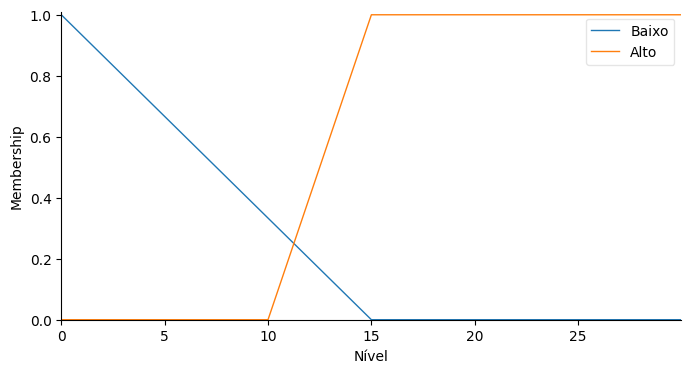

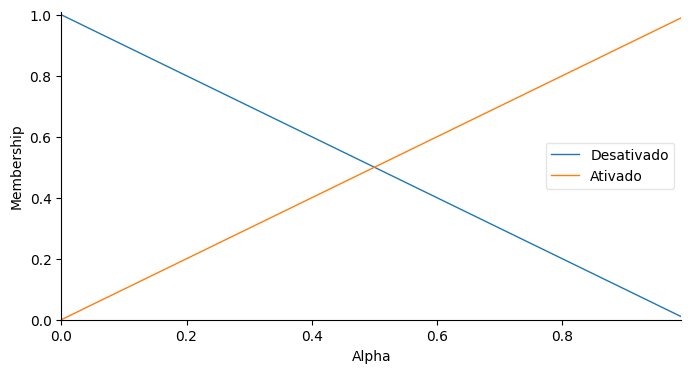

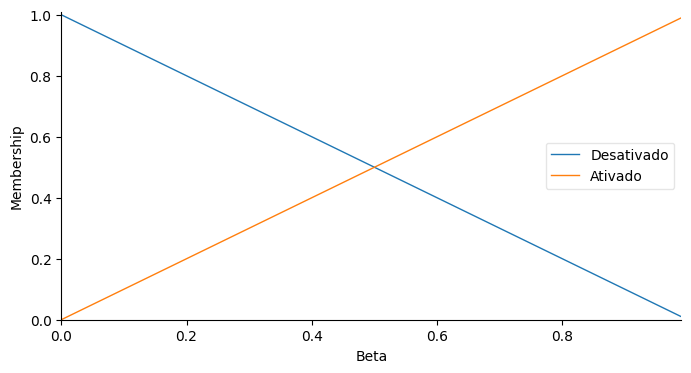

In [ ]:
plt.rcParams['figure.figsize'] = 8,4

#Definir o antecedente
input1 = ctrl.Antecedent(np.arange(0,30,0.01), 'Nível')
input1['Baixo'] = fuzz.trimf(input1.universe, [0,0,15])
input1['Alto'] = fuzz.trapmf(input1.universe, [10,15,30,30])
input1.view()

#Definir os consequentes
# Definição do parâmetro alpha <> PID1
output1 = ctrl.Consequent(np.arange(0,1,0.01), 'Alpha', defuzzify_method='centroid')
output1['Desativado'] = fuzz.trimf(output1.universe, [0,0,1])
output1['Ativado'] = fuzz.trimf(output1.universe, [0,1,1])
output1.view()

#Definir os consequentes
# Definição do parâmetro beta <> PID2
output2 = ctrl.Consequent(np.arange(0,1,0.01), 'Beta', defuzzify_method='centroid')
output2['Desativado'] = fuzz.trimf(output2.universe, [0,0,1])
output2['Ativado'] = fuzz.trimf(output2.universe, [0,1,1])
output2.view()

#Regras
rules=[]
rules.append(ctrl.Rule(input1['Baixo'], output1['Ativado']))
rules.append(ctrl.Rule(input1['Baixo'], output2['Desativado']))

rules.append(ctrl.Rule(input1['Alto'], output1['Ativado']))
rules.append(ctrl.Rule(input1['Alto'], output2['Ativado']))

#Definir controlador e ativar simulador
controller = ctrl.ControlSystem(rules)
controller_sim = ctrl.ControlSystemSimulation(controller)

In [ ]:
dt = 0.1
t = 300

sp = [5,25,15]
Init = [0,0,0,0,0] #tempo, primeiro sp, niveis dos tanques e a tensão

def sistema_hibrido(t, dt, kc, ki, kd, Set, Init, factor, controller_sim):

  it = int(t/dt)

  noise = np.random.randn(it)*factor

  t = [Init[0]]
  L_sp = [Init[1]]
  L1_hibrido = [Init[2]]
  L2_hibrido = [Init[3]]
  Vp_hibrido = [Init[4]]
  erro = [sp[0]-Init[1]]
  coefs = [[0,0]]

  #Atualização de setpoint
  for step in range(it):
    if step == 0: #primeiro terço da simulação
      sp_actual = sp[0]
      pid1 = PID(Kp=kc[0], Ki = ki[0], Kd = kd[0], setpoint = sp_actual)
      pid2 = PID(Kp=kc[1], Ki = ki[1], Kd = kd[1], setpoint = sp_actual)

    if step == int((it)/3)-1: #segundo terço da simulação
      sp_actual = sp[1]
      pid1 = PID(Kp=kc[0], Ki = ki[0], Kd = kd[0], setpoint = sp_actual)
      pid2 = PID(Kp=kc[1], Ki = ki[1], Kd = kd[1], setpoint = sp_actual)

    if step == int(2*(it)/3)-1: #terceiro terço da simulação
      sp_actual = sp[2]
      pid1 = PID(Kp=kc[0], Ki = ki[0], Kd = kd[0], setpoint = sp_actual)
      pid2 = PID(Kp=kc[1], Ki = ki[1], Kd = kd[1], setpoint = sp_actual)

    #Coefs PID1 e PID2
    aux1 = pid1(L2_hibrido[-1], dt=dt)
    aux2 = pid2(L2_hibrido[-1], dt=dt)

    #Inferência Fuzzy
    controller_sim.input['Nível'] = L2_hibrido[-1] #Entregar input
    output = controller_sim.compute() #Computar a inferência

    #Obter os outputs
    output1_resp = controller_sim.output['Alpha']
    output2_resp = controller_sim.output['Beta']

    #Reescrevendo a coeficientes (alpha/alpha+beta) e (beta/alpha+beta)
    coef_1 = output1_resp/(output1_resp + output2_resp)
    coef_2 = output2_resp/(output1_resp + output2_resp)

    #Guardando dados dos coeficientes
    coefs.append([coef_1,coef_2])

    #Ponderação das ações de controle do PID1 e do PID2
    aux = coef_1*aux1 + coef_2*aux2

    #Resolver modelo para o ponto atual
    aux2 = solver(modelo, (L1_hibrido[-1], L2_hibrido[-1]), (aux, a, A, g, Km), dt)

    #Inserção de ruído
    if (aux2[0] + noise[step] > 0) & (aux2[1] + noise[step] > 0):
          aux2[0] =  aux2[0] + noise[step] #input de ruído
          aux2[1] =  aux2[1] + noise[step] #input de ruído

    L_sp.append(sp_actual)
    Vp_hibrido.append(aux)
    L1_hibrido.append(aux2[0])
    L2_hibrido.append(aux2[1])

    erro.append(sp_actual - aux2[1])

  return [L2_hibrido, Vp_hibrido, L_sp, erro, coefs]

In [ ]:
L_hib, Vp_hib, L_sp, erro_hib, coefs = sistema_hibrido(t, dt, kc, ki, kd, sp, Init, 0, controller_sim)
L_hib_noise, Vp_hib_noise, L_sp_noise, erro_hib_noise, coefs_noise = sistema_hibrido(t, dt, kc, ki, kd, sp, Init, 0.5, controller_sim)

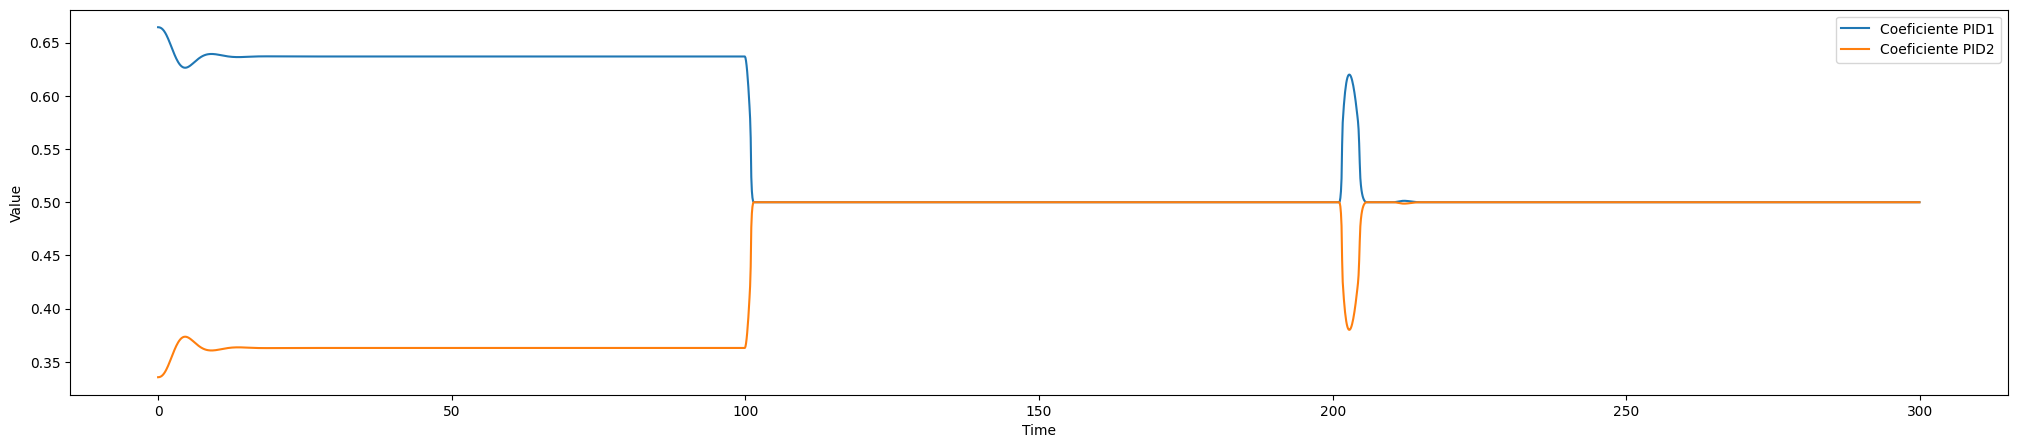

In [ ]:
coefs_vec = np.array(coefs)

plt.figure()
plt.plot(time,coefs_vec[:,0][1:],label = 'Coeficiente PID1')
plt.plot(time,coefs_vec[:,1][1:],label = 'Coeficiente PID2')
plt.ylabel('Value')
plt.xlabel('Time')
plt.legend()

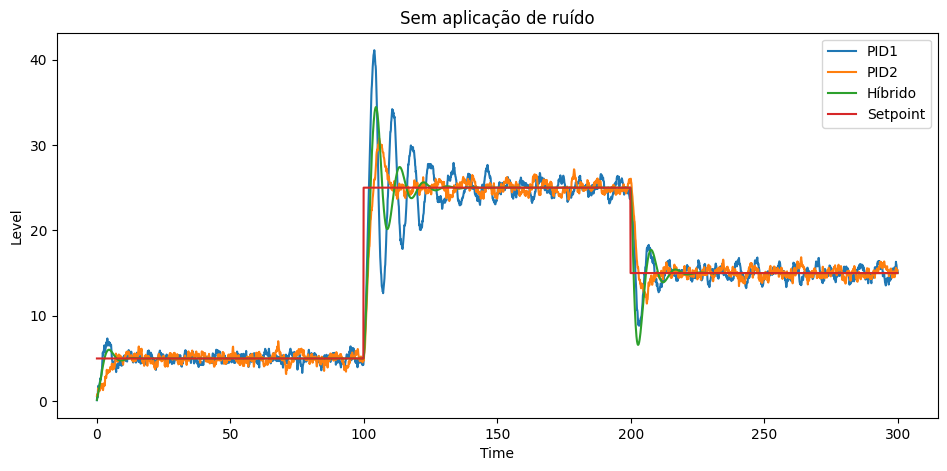

In [ ]:
plt.rcParams['figure.figsize'] = 25,5
plt.figure()

plt.subplot(1, 2, 1)
plt.plot(time,L2_pid1[1:],label = 'PID1')
plt.plot(time,L2_pid2[1:],label = 'PID2')
plt.plot(time,L_hib[1:],label = 'Híbrido')
plt.plot(time,L_sp[1:],label = 'Setpoint')
plt.ylabel('Level')
plt.xlabel('Time')
plt.legend()
plt.title('Sem aplicação de ruído')
plt.show()


# Tarefa 2

---



Agora considere um controlador Fuzzy como apresentado na figura abaixo:

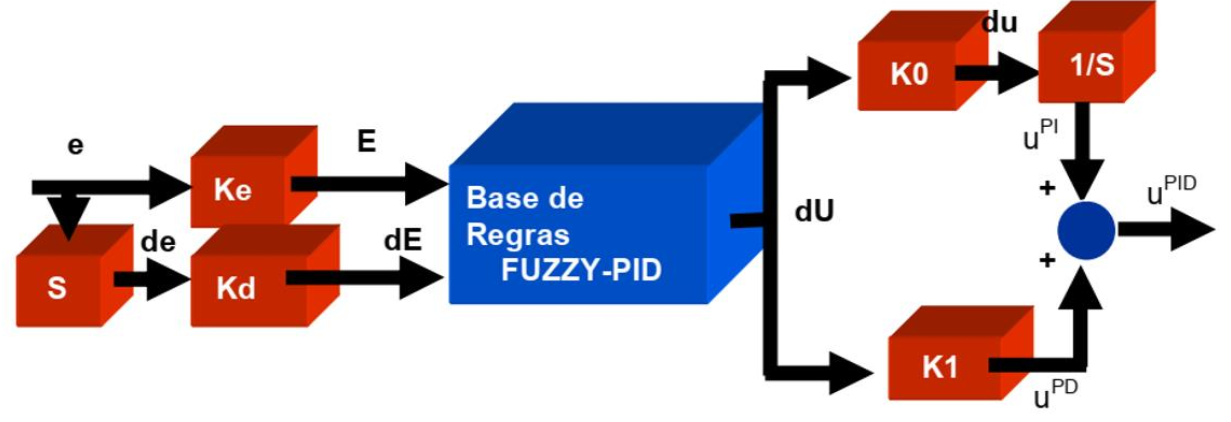

Onde $K_e$, $K_d$ , $K_0$ e $K_1$ serão determinados pelo conjunto de equações mostradas a seguir:

\begin{align*}
K_e = 1 (Inicial)
\end{align*}

\begin{align*}
K_d = \alpha K_e
\end{align*}

\begin{align*}
\alpha + \beta = T_i
\end{align*}

\begin{align*}
\beta = \dfrac{K_1}{K_0}
\end{align*}

\begin{align*}
\alpha * \beta = T_i * T_d
\end{align*}

\begin{align*}
K_0 \geq \dfrac{K_c}{T_i}
\end{align*}



A base de regras para este controlador seguirá o que está definido na tabela
abaixo:

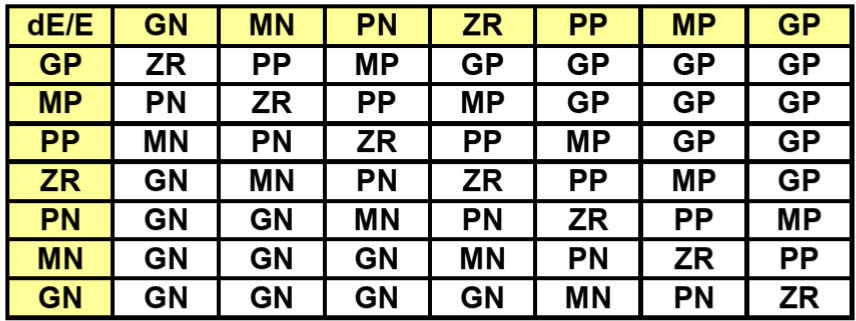

Implemente o controlador fuzzy acima, devidamente sintonizado, no processo de tanques acoplados. Analise e comente o desempenho do controlador fuzzy

In [ ]:
!pip install simple_pid

In [ ]:
!pip install scikit-fuzzy

In [ ]:
import numpy as np
import pandas as pd
from scipy.optimize import fsolve
from sympy import symbols,Eq,solve
import matplotlib.pyplot as plt
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from scipy.integrate import odeint
from simple_pid import PID
plt.rcParams['figure.figsize'] = 25,5

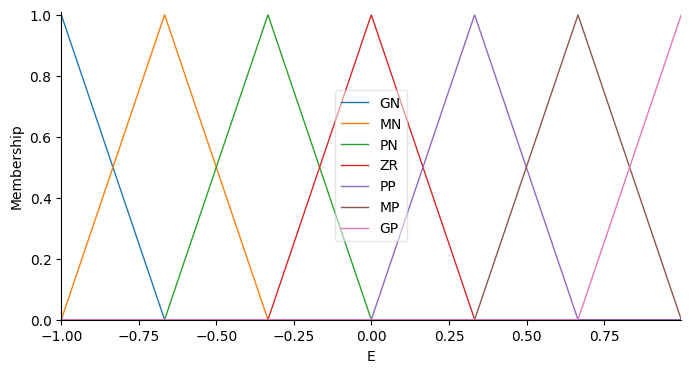

In [ ]:
plt.rcParams['figure.figsize'] = 8,4

#Definir inputs e outputs
#Erro
input1 = ctrl.Antecedent(np.arange(-1,1,0.001), 'E')
input1.automf(names=['GN','MN','PN','ZR','PP','MP','GP'])
input1.view()

#Variação do erro
input2 = ctrl.Antecedent(np.arange(-1,1,0.001), 'dE')
input2.automf(names=['GN','MN','PN','ZR','PP','MP','GP'])
# input2.view()

#dU
output = ctrl.Consequent(np.arange(-1,1,0.001), 'dU', defuzzify_method='centroid')
output.automf(names=['GN','MN','PN','ZR','PP','MP','GP'])
# output.view()

rules=[]

#Coluna GN
rules.append(ctrl.Rule(input1['GN'] & input2['GP'], output['ZR']))
rules.append(ctrl.Rule(input1['GN'] & input2['MP'], output['PN']))
rules.append(ctrl.Rule(input1['GN'] & input2['PP'], output['MN']))
rules.append(ctrl.Rule(input1['GN'] & (input2['ZR'] | input2['PN'] | input2['MN']| input2['GN']), output['GN']))

#Coluna MN
rules.append(ctrl.Rule(input1['MN'] & input2['GP'], output['PP']))
rules.append(ctrl.Rule(input1['MN'] & input2['MP'], output['ZR']))
rules.append(ctrl.Rule(input1['MN'] & input2['PP'], output['PN']))
rules.append(ctrl.Rule(input1['MN'] & input2['ZR'], output['MN']))
rules.append(ctrl.Rule(input1['MN'] & (input2['PN'] | input2['MN']| input2['GN']), output['GN']))

#Coluna PN
rules.append(ctrl.Rule(input1['PN'] & input2['GP'], output['MP']))
rules.append(ctrl.Rule(input1['PN'] & input2['MP'], output['PP']))
rules.append(ctrl.Rule(input1['PN'] & input2['PP'], output['ZR']))
rules.append(ctrl.Rule(input1['PN'] & input2['ZR'], output['PN']))
rules.append(ctrl.Rule(input1['PN'] & input2['PN'], output['MN']))
rules.append(ctrl.Rule(input1['PN'] & (input2['MN']| input2['GN']), output['GN']))

#Coluna ZR
rules.append(ctrl.Rule(input1['ZR'] & input2['GP'], output['GP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['MP'], output['MP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['PP'], output['PP']))
rules.append(ctrl.Rule(input1['ZR'] & input2['ZR'], output['ZR']))
rules.append(ctrl.Rule(input1['ZR'] & input2['PN'], output['PN']))
rules.append(ctrl.Rule(input1['ZR'] & input2['MN'], output['MN']))
rules.append(ctrl.Rule(input1['ZR'] & input2['GN'], output['GN']))

#Coluna PP
rules.append(ctrl.Rule(input1['PP'] & (input2['GP'] | input2['MP']), output['GP']))
rules.append(ctrl.Rule(input1['PP'] & input2['PP'], output['MP']))
rules.append(ctrl.Rule(input1['PP'] & input2['ZR'], output['PP']))
rules.append(ctrl.Rule(input1['PP'] & input2['PN'], output['ZR']))
rules.append(ctrl.Rule(input1['PP'] & input2['MN'], output['PN']))
rules.append(ctrl.Rule(input1['PP'] & input2['GN'], output['MN']))

#Coluna MP
rules.append(ctrl.Rule(input1['MP'] & (input2['GP'] | input2['MP'] | input2['PP']), output['GP']))
rules.append(ctrl.Rule(input1['MP'] & input2['ZR'], output['MP']))
rules.append(ctrl.Rule(input1['MP'] & input2['PN'], output['PP']))
rules.append(ctrl.Rule(input1['MP'] & input2['MN'], output['ZR']))
rules.append(ctrl.Rule(input1['MP'] & input2['GN'], output['PN']))

#Coluna GP
rules.append(ctrl.Rule(input1['GP'] & (input2['GP'] | input2['MP'] | input2['PP']| input2['ZR']), output['GP']))
rules.append(ctrl.Rule(input1['GP'] & input2['PN'], output['MP']))
rules.append(ctrl.Rule(input1['GP'] & input2['MN'], output['PP']))
rules.append(ctrl.Rule(input1['GP'] & input2['GN'], output['ZR']))

controller = ctrl.ControlSystem(rules)
controller_sim = ctrl.ControlSystemSimulation(controller)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/skfuzzy/control/fuzzyvariable.py:125: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


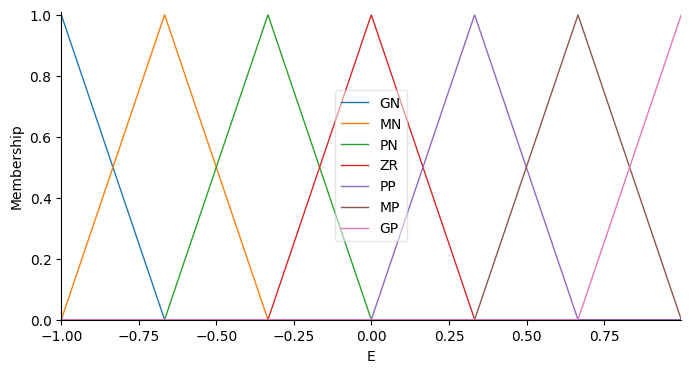

In [ ]:
#plot funções de pertinencia
input1.view()
# input2.view()
# output.view()

In [ ]:
sp = [5, 25, 15]
Init = [0]*5
t = 300
dt = 0.1


def contr_fuzzy(t, dt, Ke, K0, K1, Kd, Init, factor, controller_sim):

  it = int(t/dt)

  noise = np.random.randn(it)*factor #Evita valores negativos

  uPI, uPD = 0, 0

  t = [Init[0]]*2
  L_sp = [Init[1]]*2
  L1_Fzy = [Init[2]]*2
  L2_Fzy = [Init[3]]*2
  Vp_Fzy = [Init[4]]*2
  erro = [sp[0]-Init[1]]*2

  for i in range(it):
    if i == 0: sp_actual = sp[0]
    if i == int(it/3)-1: sp_actual = sp[1]
    if i == int(2*it/3)-1: sp_actual = sp[2]

    #Observação importante! Valores já estão normalizados [0,1] = nivel do tanque
    #Portanto, erro ja vai de -1 a 1

    controller_sim.input['E'] = erro[-1] * Ke
    controller_sim.input['dE'] = np.diff(erro)[-1] * Kd
    output = controller_sim.compute()

    dU_fuzzy = controller_sim.output['dU']

    uPI = (dU_fuzzy*K0) + uPI
    uPD = dU_fuzzy * (K1)

    MV = uPI + uPD

    L_new = solver(modelo, (L1_Fzy[-1], L2_Fzy[-1]), (MV , a, A, g, Km), dt)
    aux2 = L_new[0] #Nivel 1
    aux3 = L_new[1] #Nivel 2

    if (aux2 + noise[i] > 0) & (aux3 + noise[i] > 0):
      aux2 =  aux2 + noise[i] #input de ruído
      aux3 =  aux3 + noise[i] #input de ruído

    L_sp.append(sp_actual)
    Vp_Fzy.append(MV)
    L1_Fzy.append(aux2)
    L2_Fzy.append(aux3)
    erro.append(sp_actual - aux3)

  del Vp_Fzy[0], L2_Fzy[0], erro[0], L_sp[0] #para manter as listas todas com o mesmo tamanho
  return [L2_Fzy, Vp_Fzy, L_sp, erro]

Kc = 25
Ke = 0.5
Ti = 10
beta = 18
alpha = 12

K0 = Kc/Ti
K1 = K0 * beta
Kd = alpha*Ke

L_fuzzy, Vp_fuzzy, L_sp, erro_fuzzy = contr_fuzzy(t, dt, Ke, K0, K1, Kd, Init, 0, controller_sim)
L_fuzzy_noise, Vp_fuzzy_noise, L_sp, erro_fuzzy_noise = contr_fuzzy(t, dt, Ke, K0, K1, Kd, Init, 0.25, controller_sim)

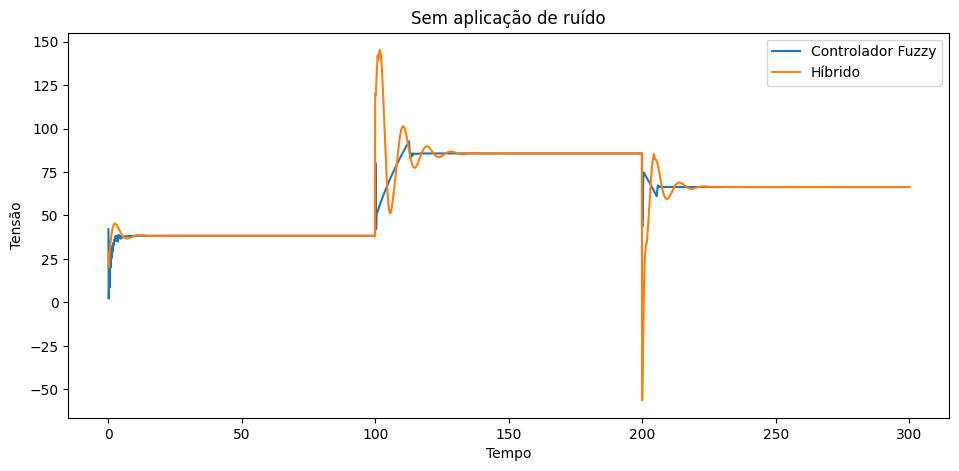

In [ ]:
plt.rcParams['figure.figsize'] = 25,5
plt.figure()

plt.subplot(1, 2, 1)
plt.plot(time,Vp_fuzzy[1:],label = 'Controlador Fuzzy')
plt.plot(time,Vp_hib[1:],label = 'Híbrido')
plt.ylabel('Tensão')
plt.xlabel('Tempo')
plt.legend()
plt.title('Sem aplicação de ruído')
plt.show()

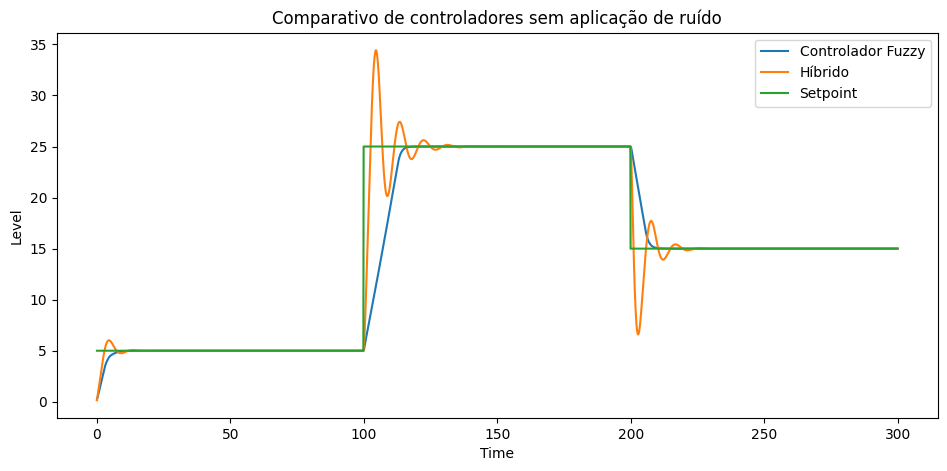

In [ ]:
plt.rcParams['figure.figsize'] = 25,5
plt.figure()

plt.subplot(1, 2, 1)
plt.plot(time,L_fuzzy[1:],label = 'Controlador Fuzzy')
plt.plot(time,L_hib[1:],label = 'Híbrido')
plt.plot(time,L_sp[1:],label = 'Setpoint')
plt.ylabel('Level')
plt.xlabel('Time')
plt.legend()
plt.title('Comparativo de controladores sem aplicação de ruído')
plt.show()

In [ ]:
#Criar DataFrame com as métricas de desempenho IAE, ISE, ITAE e ITSE
def performance_metrics(erro, time):
    erro = np.array(erro)
    IAE = np.sum(np.abs(erro))
    ISE = np.sum(erro**2)
    ITAE = np.sum(time * np.abs(erro))
    ITSE = np.sum(time * (erro**2))
    return IAE, ISE, ITAE, ITSE

#Excluir primeiro dado de erro para alinhar com o tempo
erro_corr = erro_fuzzy[1:]
erro_noise_corr = erro_fuzzy_noise[1:]

metrics_fuzzy = performance_metrics(erro_corr, time)
metrics_fuzzy_noise = performance_metrics(erro_noise_corr, time)

#Criar DataFrame com as métricas PID1, PID2, Híbrido e Fuzzy, todos sem ruído
df_metrics_all = pd.DataFrame({
    'PID1': metrics_pid1,
    'PID2': metrics_pid2,
    'Híbrido': performance_metrics(erro_hib[1:], time),
    'Fuzzy': metrics_fuzzy,
}, index=['IAE', 'ISE', 'ITAE', 'ITSE'])

#Garantir que todos os numeros são float truncados para 2 casas decimais
df_metrics_all = df_metrics_all.astype(float).round(2)

df_metrics_all

,PID1,PID2,Híbrido,Fuzzy
IAE,3430.62,2149.68,1368.45,1936.05
ISE,17027.96,8064.07,9310.06,22149.99
ITAE,476502.48,294892.69,177110.88,225116.31
ITSE,2023067.50,960518.50,1155879.64,2489570.49


In [ ]:
#Avaliar esforço do controlador (ação de controle) para todos os controladores
def control_effort(V):
    V = np.array(V)
    effort = np.sum(np.abs(np.diff(V)))
    return effort

effort_pid1 = control_effort(V_pid1)
effort_pid2 = control_effort(V_pid2)
effort_hib = control_effort(Vp_hib[1:])
effort_fuzzy = control_effort(Vp_fuzzy[1:])

df_effort = pd.DataFrame({
    'PID1': [effort_pid1],
    'PID2': [effort_pid2],
    'Híbrido': [effort_hib],
    'Fuzzy': [effort_fuzzy]
}, index=['Control Effort'])

df_effort

,PID1,PID2,Híbrido,Fuzzy
Control Effort,67817.454824,69501.557405,675.852195,436.087961
